Выбран датасет "Дорожно-транспортные происшествия: координаты, участники и пострадавшие" с сайта [https://tochno.st/datasets/traffic_accidents](https://tochno.st/datasets/traffic_accidents). Из предоставленных файлов будет использоваться только "accidents_all_regions_126_v20260901.csv" с использованием только первых 500 строк.


In [1]:
# 1. Создать отдельное виртуальное окружение или использовать базовое окружение курса; зафиксировать версии Python и библиотек.
import sys
import pandas as pd
import numpy as np
import matplotlib

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)


Python: 3.13.5
pandas: 3.0.5
NumPy: 2.5.2
Matplotlib: 3.11.1


In [2]:
# 2. Загрузить исходный файл. Если формат не CSV, объяснить особенности чтения. Для CSV явно проверить разделитель, кодировку и распознавание типов.
df = pd.read_csv(
    'accidents_all_regions_126_v20260901.csv',
    sep=';',
    encoding='utf-8'
)


In [3]:
# 3. Сформировать «паспорт данных», который включает такие категории как: источник, предметная область, размер таблицы, перечень признаков и их предполагаемый смысл.
print("Источник: https://tochno.st/datasets/traffic_accidents")
print("Предметная область: дорожно-транспортные происшествия в России (первые 500 записей)")
print(f"Размер таблицы: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПеречень признаков и их предполагаемый смысл:")

col_descriptions = {
    'id': 'Уникальный идентификатор ДТП (целое число)',
    'tags': 'Тематический тег — всегда "Дорожно-транспортные происшествия" (категориальный)',
    'category': 'Тип ДТП (например, Столкновение, Наезд на пешехода, Наезд на препятствие и т.д.) — категориальный',
    'region': 'Регион РФ (категориальный)',
    'county': 'Район или город (категориальный)',
    'address': 'Адрес происшествия (текстовый)',
    'longitude': 'Географическая долгота (числовой, float)',
    'latitude': 'Географическая широта (числовой, float)',
    'nearby': 'Наличие объектов поблизости (текстовый, могут быть пропуски)',
    'datetime': 'Дата и время ДТП (строка, будет преобразована в datetime)',
    'light': 'Условия освещения (категориальный)',
    'weather': 'Погодные условия (категориальный, могут быть пропуски)',
    'road_conditions': 'Состояние дорожного покрытия (категориальный, могут быть пропуски)',
    'participants_count': 'Количество участников ДТП (целое число)',
    'participant_categories': 'Категории участников (например, "Все участники", "Пешеходы") — категориальный',
    'severity': 'Тяжесть происшествия (Лёгкий, Тяжёлый) — категориальный',
    'dead_count': 'Число погибших (целое число)',
    'injured_count': 'Число раненых (целое число)'
}

for col, desc in col_descriptions.items():
    print(f"  {col:20s} : {desc}")

print("\nТипы данных, распознанные при загрузке:")
print(df.dtypes)
print("\nПредварительная оценка пропусков (количество NaN):")
print(df.isna().sum())


Источник: https://tochno.st/datasets/traffic_accidents
Предметная область: дорожно-транспортные происшествия в России (первые 500 записей)
Размер таблицы: 500 строк, 18 столбцов

Перечень признаков и их предполагаемый смысл:
  id                   : Уникальный идентификатор ДТП (целое число)
  tags                 : Тематический тег — всегда "Дорожно-транспортные происшествия" (категориальный)
  category             : Тип ДТП (например, Столкновение, Наезд на пешехода, Наезд на препятствие и т.д.) — категориальный
  region               : Регион РФ (категориальный)
  county               : Район или город (категориальный)
  address              : Адрес происшествия (текстовый)
  longitude            : Географическая долгота (числовой, float)
  latitude             : Географическая широта (числовой, float)
  nearby               : Наличие объектов поблизости (текстовый, могут быть пропуски)
  datetime             : Дата и время ДТП (строка, будет преобразована в datetime)
  light       

Датасет содержит 500 строк и 18 столбцов. Среди признаков есть числовые (participants_count, dead_count, injured_count), категориальные (category, light, weather), географические (lon, lat) и временная метка (datetime). Пропуски обнаружены только в столбце address (13 записей). Это позволяет выполнить все запланированные виды анализа.


In [4]:
# 4. Выполнить базовые методы head(), info(), describe(include="all") или эквивалентный набор диагностик.
print("\nhead()")
display(df.head())

print("\ninfo")
import io
buf = io.StringIO()
df.info(buf=buf, memory_usage="deep")
print(buf.getvalue())

print("\ndescribe(include=\"all\")")
display(df.describe(include='all').round(2))



head()


,id,tags,category,region,county,address,longitude,latitude,nearby,datetime,light,weather,road_conditions,participants_count,participant_categories,severity,dead_count,injured_count
0,160,Дорожно-транспортные происшествия,Столкновение,Магаданская область,Магадан,"Магадан, Р-504 Колыма Якутск - Магадан, 1976км",1.000000,1.000000,Отсутствие в непосредственной близости объекто...,2015-01-01 06:30:00,"В темное время суток, освещение отсутствует",Ясно,Не установлены,3,Все участники,Легкий,0,1
1,514,Дорожно-транспортные происшествия,Наезд на препятствие,Магаданская область,Магадан,"г Магадан, ул Приморская, 1 А",150.123889,59.918056,Отсутствие в непосредственной близости объекто...,2015-01-02 01:20:00,"В темное время суток, освещение включено",Пасмурно,Не установлены,2,Все участники,Легкий,0,1
2,539,Дорожно-транспортные происшествия,Наезд на препятствие,Магаданская область,Магадан,"г Магадан, ул Речная, 63-1",150.122500,59.085000,Отсутствие в непосредственной близости объекто...,2015-01-02 03:50:00,"В темное время суток, освещение включено",Ясно,Не установлены,2,Все участники,Тяжёлый,0,1
3,683,Дорожно-транспортные происшествия,Столкновение,Магаданская область,Магадан,"г Магадан, ул Полярная, 18",150.790833,59.561667,Отсутствие в непосредственной близости объекто...,2015-01-02 14:25:00,Светлое время суток,Пасмурно,"Отсутствие, плохая различимость горизонтальной...",4,Все участники,Легкий,0,1
4,1328,Дорожно-транспортные происшествия,Наезд на пешехода,Магаданская область,Магадан,"Магадан, Р-504 Колыма Якутск - Магадан, 2017км",150.913333,59.605000,Отсутствие в непосредственной близости объекто...,2015-01-03 19:55:00,"В темное время суток, освещение отсутствует",Ясно,Не установлены,2,"Все участники, Пешеходы",Тяжёлый,0,1



info
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      500 non-null    int64  
 1   tags                    500 non-null    str    
 2   category                500 non-null    str    
 3   region                  500 non-null    str    
 4   county                  500 non-null    str    
 5   address                 487 non-null    str    
 6   longitude               500 non-null    float64
 7   latitude                500 non-null    float64
 8   nearby                  500 non-null    str    
 9   datetime                500 non-null    str    
 10  light                   500 non-null    str    
 11  weather                 500 non-null    str    
 12  road_conditions         500 non-null    str    
 13  participants_count      500 non-null    int64  
 14  participant_categories  500 non-null    str    

,id,tags,category,region,county,address,longitude,latitude,nearby,datetime,light,weather,road_conditions,participants_count,participant_categories,severity,dead_count,injured_count
count,500.00,500,500,500,500,487,500.00,500.00,500,500,500,500,500,500.00,500,500,500.00,500.00
unique,NaN,1,9,1,9,402,NaN,NaN,28,499,6,10,18,NaN,8,3,NaN,NaN
top,NaN,Дорожно-транспортные происшествия,Столкновение,Магаданская область,Магадан,"г Магадан, пр-кт Ленина, 3",NaN,NaN,Отсутствие в непосредственной близости объекто...,2016-08-31 15:00:00,Светлое время суток,Ясно,Не установлены,NaN,Все участники,Легкий,NaN,NaN
freq,NaN,500,158,500,375,5,NaN,NaN,281,2,305,339,351,NaN,324,281,NaN,NaN
mean,170099.66,NaN,NaN,NaN,NaN,NaN,150.37,59.85,NaN,NaN,NaN,NaN,NaN,2.41,NaN,NaN,0.12,1.34
std,95603.17,NaN,NaN,NaN,NaN,NaN,7.51,2.88,NaN,NaN,NaN,NaN,NaN,1.33,NaN,NaN,0.38,0.98
min,160.00,NaN,NaN,NaN,NaN,NaN,1.00,1.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,0.00,0.00
25%,85028.25,NaN,NaN,NaN,NaN,NaN,150.79,59.56,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN,0.00,1.00
50%,178685.50,NaN,NaN,NaN,NaN,NaN,150.81,59.57,NaN,NaN,NaN,NaN,NaN,2.00,NaN,NaN,0.00,1.00
75%,254383.75,NaN,NaN,NaN,NaN,NaN,150.84,59.67,NaN,NaN,NaN,NaN,NaN,3.00,NaN,NaN,0.00,1.00


Метод info() показал, что все столбцы, кроме address, заполнены полностью. Память составляет ~0.38 МБ. describe(include='all') выявил, что наиболее частые категории ДТП — «Столкновение» (158) и «Наезд на пешехода» (135). В выборке преобладают ДТП в светлое время суток (305 из 500). Число пострадавших в среднем 1.34, максимум — 10 человек.


In [5]:
# 5. Посчитать пропуски, полные дубликаты и число уникальных значений по каждому столбцу. Обосновать каждое принятое действие с пропусками/дубликатами.
print("\nПропуски по столбцам (количество NaN)")
print(df.isna().sum())

print("\nКоличество полных дубликатов")
print(df.duplicated().sum())

print("\nЧисло уникальных значений по каждому столбцу")
for col in df.columns:
    print(f"{col:20s} : {df[col].nunique()}")



Пропуски по столбцам (количество NaN)
id                         0
tags                       0
category                   0
region                     0
county                     0
address                   13
longitude                  0
latitude                   0
nearby                     0
datetime                   0
light                      0
weather                    0
road_conditions            0
participants_count         0
participant_categories     0
severity                   0
dead_count                 0
injured_count              0
dtype: int64

Количество полных дубликатов
0

Число уникальных значений по каждому столбцу
id                   : 500
tags                 : 1
category             : 9
region               : 1
county               : 9
address              : 402
longitude            : 434
latitude             : 406
nearby               : 28
datetime             : 499
light                : 6
weather              : 10
road_conditions      : 18
participan

Пропуски есть только в address (13), дубликатов нет. Уникальных значений: category — 9, light — 6, weather — 10, road_conditions — 18. region содержит только одно значение («Магаданская область»), что указывает на локальность выборки. Столбец tags всегда имеет одно значение, его можно удалить, но оставим для сохранения структуры.


In [6]:
# 6. Проверить и при необходимости изменить dtypes. Сравнить память до и после хотя бы одной обоснованной оптимизации.
before = df.memory_usage(deep=True).sum()
opt_df = df.copy()

cat_cols = ['category', 'county', 'light', 'weather', 'road_conditions',
            'participant_categories', 'severity']
for col in cat_cols:
    opt_df[col] = opt_df[col].astype('category')

int_cols = ['participants_count', 'dead_count', 'injured_count']
for col in int_cols:
    opt_df[col] = opt_df[col].astype('int8')

# id можно сделать int32 (диапазон до 331320)
opt_df['id'] = opt_df['id'].astype('int32')

after = opt_df.memory_usage(deep=True).sum()

print(f"До оптимизации: {before / 1024**2:.2f} MiB")
print(f"После оптимизации: {after / 1024**2:.2f} MiB")
print(f"Снижение: {(1 - after/before) * 100:.1f}%")

print("\nТипы после оптимизации:")
print(opt_df.dtypes)


До оптимизации: 0.38 MiB
После оптимизации: 0.25 MiB
Снижение: 33.9%

Типы после оптимизации:
id                           int32
tags                           str
category                  category
region                         str
county                    category
address                        str
longitude                  float64
latitude                   float64
nearby                         str
datetime                       str
light                     category
weather                   category
road_conditions           category
participants_count            int8
participant_categories    category
severity                  category
dead_count                    int8
injured_count                 int8
dtype: object


Оптимизация типов (преобразование категориальных в category, целочисленных в int8, id в int32) уменьшила память с 0.38 МБ до 0.25 МБ (снижение на 33.9%). Это показывает, что грамотный выбор dtype важен для эффективной работы с данными.


In [7]:
# 7. Создать минимум один вычисляемый признак с явной формулой или логическим правилом и объяснить его смысл.
opt_df['datetime'] = pd.to_datetime(opt_df['datetime'])
opt_df['total_victims'] = opt_df['dead_count'] + opt_df['injured_count']
opt_df['hour'] = opt_df['datetime'].dt.hour
opt_df['day_of_week'] = opt_df['datetime'].dt.dayofweek  # 0=пн, 6=вс
opt_df['is_fatal'] = opt_df['dead_count'] > 0

print("Добавлены новые столбцы:")
print(opt_df[['datetime', 'dead_count', 'injured_count', 'total_victims', 'hour', 'day_of_week', 'is_fatal']].head())
print("\nТипы новых столбцов:")
print(opt_df[['total_victims', 'hour', 'day_of_week', 'is_fatal']].dtypes)
print(f"\nОбщее число пострадавших (сумма): {opt_df['total_victims'].sum()}")
print(f"Доля ДТП с погибшими: {opt_df['is_fatal'].mean():.2%}")


Добавлены новые столбцы:
             datetime  dead_count  injured_count  total_victims  hour  \
0 2015-01-01 06:30:00           0              1              1     6   
1 2015-01-02 01:20:00           0              1              1     1   
2 2015-01-02 03:50:00           0              1              1     3   
3 2015-01-02 14:25:00           0              1              1    14   
4 2015-01-03 19:55:00           0              1              1    19   

   day_of_week  is_fatal  
0            3     False  
1            4     False  
2            4     False  
3            4     False  
4            5     False  

Типы новых столбцов:
total_victims     int8
hour             int32
day_of_week      int32
is_fatal          bool
dtype: object

Общее число пострадавших (сумма): 730
Доля ДТП с погибшими: 10.60%


Добавлены признаки total_victims (общее число пострадавших), hour, day_of_week, is_fatal (наличие погибших). Общее число пострадавших в выборке — 730, доля ДТП с погибшими — 10.6%. Эти признаки позволяют анализировать временные закономерности и тяжесть происшествий.


In [8]:
# 8. Построить минимум один составной фильтр через loc/query и интерпретировать число полученных строк.
subset_loc = opt_df.loc[
    (opt_df['total_victims'] > 0) &
    (opt_df['light'] == 'В темное время суток, освещение отсутствует'),
    ['datetime', 'category', 'severity', 'total_victims', 'light']
]
print(f"Число строк, удовлетворяющих условию (ДТП с пострадавшими в темноте без освещения): {len(subset_loc)}")
print(subset_loc.head())

subset_query = opt_df.query('total_victims > 0 and light == "В темное время суток, освещение отсутствует"')
print(f"\nЧисло строк, удовлетворяющих условию (ДТП с пострадавшими в темноте без освещения): {len(subset_query)}")
print(subset_query[['datetime', 'category', 'severity', 'total_victims', 'light']].head())

print("\nИнтерпретация:")
if len(subset_loc) > 0:
    print(f"В выборке из 500 записей {len(subset_loc)} ДТП с пострадавшими произошли в условиях темноты без освещения. Это составляет {len(subset_loc)/len(opt_df)*100:.1f}% от всех ДТП.")
    print("Это показывает, что отсутствие освещения может быть фактором риска, но для подтверждения нужен более глубокий анализ.")
else:
    print("В выборке нет ДТП с пострадавшими в условиях темноты без освещения.")


Число строк, удовлетворяющих условию (ДТП с пострадавшими в темноте без освещения): 54
              datetime           category     severity  total_victims  \
0  2015-01-01 06:30:00       Столкновение       Легкий              1   
4  2015-01-03 19:55:00  Наезд на пешехода      Тяжёлый              1   
6  2015-01-07 02:00:00       Столкновение       Легкий              2   
42 2015-03-16 19:20:00       Столкновение      Тяжёлый              6   
44 2015-03-25 23:45:00     Съезд с дороги  С погибшими              2   

                                          light  
0   В темное время суток, освещение отсутствует  
4   В темное время суток, освещение отсутствует  
6   В темное время суток, освещение отсутствует  
42  В темное время суток, освещение отсутствует  
44  В темное время суток, освещение отсутствует  

Число строк, удовлетворяющих условию (ДТП с пострадавшими в темноте без освещения): 54
              datetime           category     severity  total_victims  \
0  2015-01-01

Составной фильтр (ДТП с пострадавшими и без освещения) выделил 54 записи (10.8% от всех ДТП). Среди них есть случаи с 6 пострадавшими. Это указывает на потенциальную опасность тёмного времени суток без освещения, но для окончательных выводов требуется больше данных.


In [9]:
# 9. Выполнить минимум две группировки/агрегации, одна из которых должна использовать несколько агрегатных функций.
# Группировка 1: по категории ДТП с несколькими агрегатами
group1 = (opt_df.groupby('category', observed=True)
          .agg(
              count=('id', 'size'),
              avg_participants=('participants_count', 'mean'),
              avg_victims=('total_victims', 'mean'),
              max_victims=('total_victims', 'max'),
              fatal_rate=('is_fatal', 'mean')
          )
          .sort_values('count', ascending=False)
          .round(2))
print("Группировка 1: по категории ДТП")
print(group1)

# Группировка 2: по типу освещения с несколькими агрегатами
group2 = (opt_df.groupby('light', observed=True)
          .agg(
              count=('id', 'size'),
              avg_victims=('total_victims', 'mean'),
              max_victims=('total_victims', 'max'),
              fatal_rate=('is_fatal', 'mean')
          )
          .sort_values('count', ascending=False)
          .round(2))
print("\nГруппировка 2: по типу освещения")
print(group2)


Группировка 1: по категории ДТП
                        count  avg_participants  avg_victims  max_victims  \
category                                                                    
Столкновение              158              3.12         1.70            8   
Наезд на пешехода         135              2.11         1.05            3   
Опрокидывание              69              2.10         1.75           10   
Съезд с дороги             68              1.90         1.47            3   
Наезд на препятствие       35              1.77         1.46            3   
Наезд на стоящее ТС        24              2.88         1.50            4   
Наезд на велосипедиста      6              2.00         1.00            1   
Иной вид ДТП                3              1.67         1.00            1   
Падение пассажира           2              2.00         1.00            1   

                        fatal_rate  
category                            
Столкновение                  0.09  
Наезд на 

Группировка по категориям ДТП показала, что столкновения — самые частые (158), а опрокидывания и съезды с дороги имеют наибольшую долю погибших (16% и 18% соответственно). По типу освещения: ДТП в тёмное время без освещения имеют самую высокую долю погибших (17%) по сравнению с 10% в светлое время. Это подтверждает важность освещения.


In [10]:
# 10. Исследовать не менее двух числовых признаков: описательная статистика, корреляция и один способ поиска потенциальных выбросов.
num_cols = ['participants_count', 'dead_count', 'injured_count', 'total_victims', 'hour', 'day_of_week']

print("\nОписательная статистика числовых признаков")
print(opt_df[num_cols].describe().round(2))

print("\nКорреляционная матрица")
corr = opt_df[num_cols].corr()
print(corr.round(3))

print("\nПоиск выбросов для total_victims (IQR)")
q1 = opt_df['total_victims'].quantile(0.25)
q3 = opt_df['total_victims'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = opt_df[(opt_df['total_victims'] < lower) | (opt_df['total_victims'] > upper)]
print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")
print(f"Границы: [{lower:.2f}; {upper:.2f}]")
print(f"Число выбросов: {len(outliers)} ({len(outliers)/len(opt_df)*100:.2f}%)")
print("Первые 5 выбросов:")
print(outliers[['datetime', 'category', 'total_victims', 'dead_count', 'injured_count']].head())



Описательная статистика числовых признаков
       participants_count  dead_count  injured_count  total_victims    hour  \
count              500.00      500.00         500.00         500.00  500.00   
mean                 2.41        0.12           1.34           1.46   13.34   
std                  1.33        0.38           0.98           1.02    6.40   
min                  1.00        0.00           0.00           1.00    0.00   
25%                  2.00        0.00           1.00           1.00    9.00   
50%                  2.00        0.00           1.00           1.00   14.00   
75%                  3.00        0.00           1.00           2.00   18.00   
max                 16.00        3.00          10.00          10.00   23.00   

       day_of_week  
count       500.00  
mean          3.10  
std           2.09  
min           0.00  
25%           1.00  
50%           3.00  
75%           5.00  
max           6.00  

Корреляционная матрица
                    participant

Корреляция между participants_count и total_victims = 0.676, между injured_count и total_victims = 0.93 — ожидаемо. Время суток (hour) и день недели почти не коррелируют с тяжестью. Правило IQR выявило 18 выбросов (3.6%) с числом пострадавших > 3.5. Это случаи массовых ДТП, которые требуют отдельного рассмотрения.


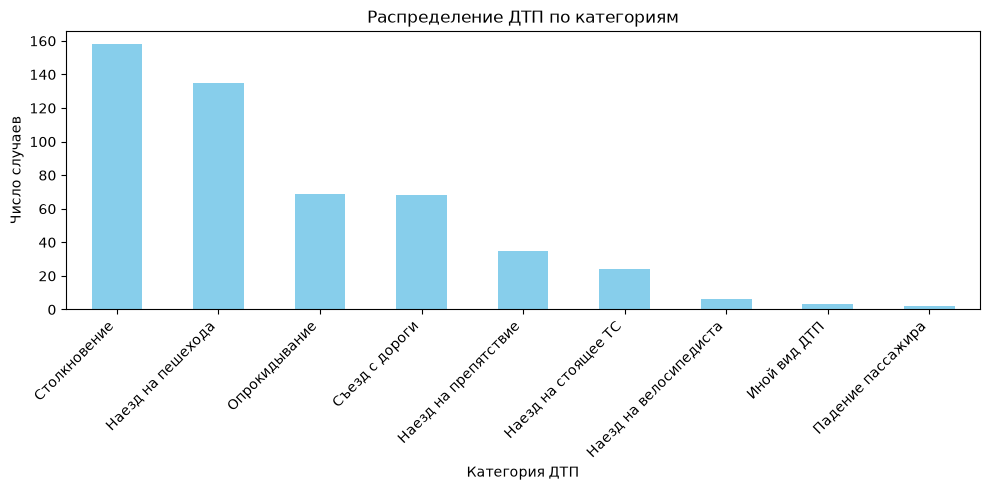

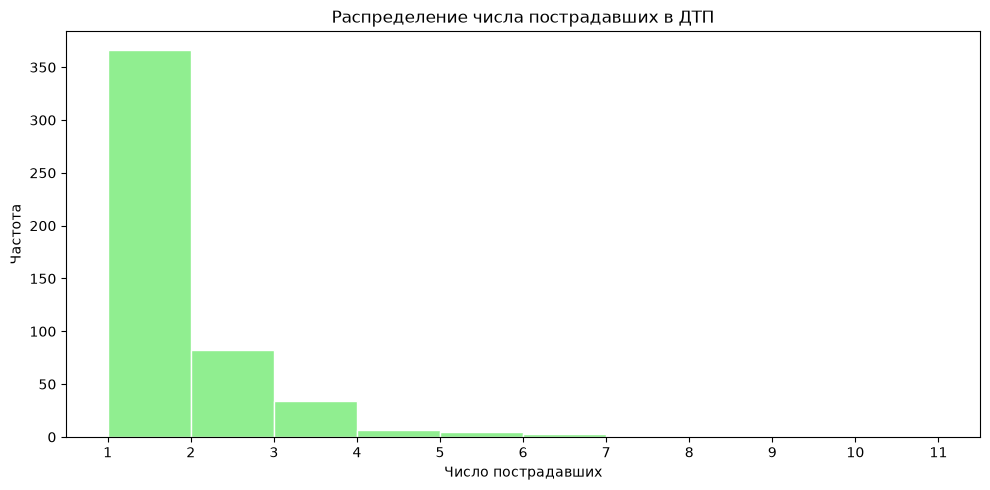

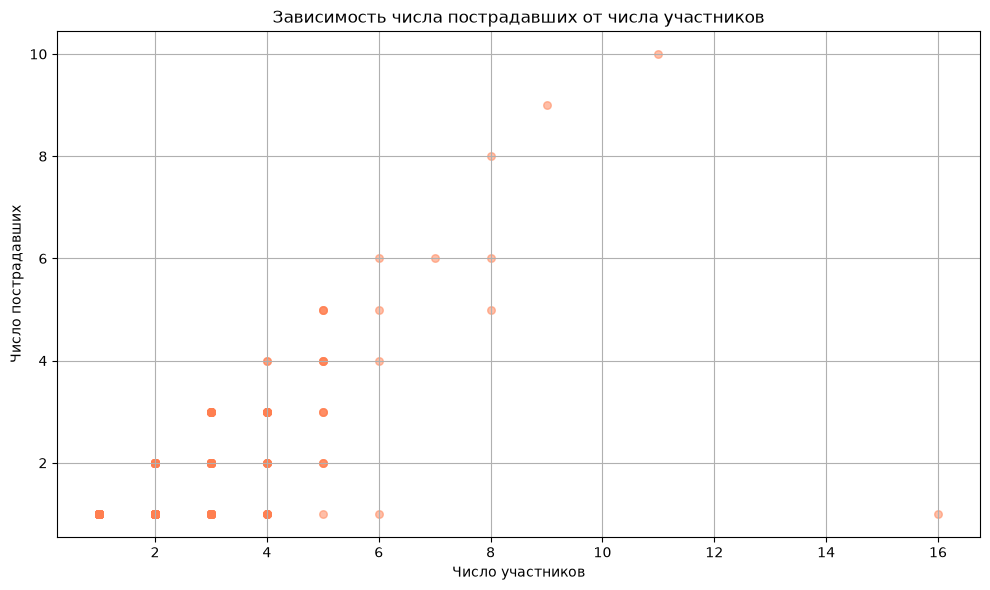

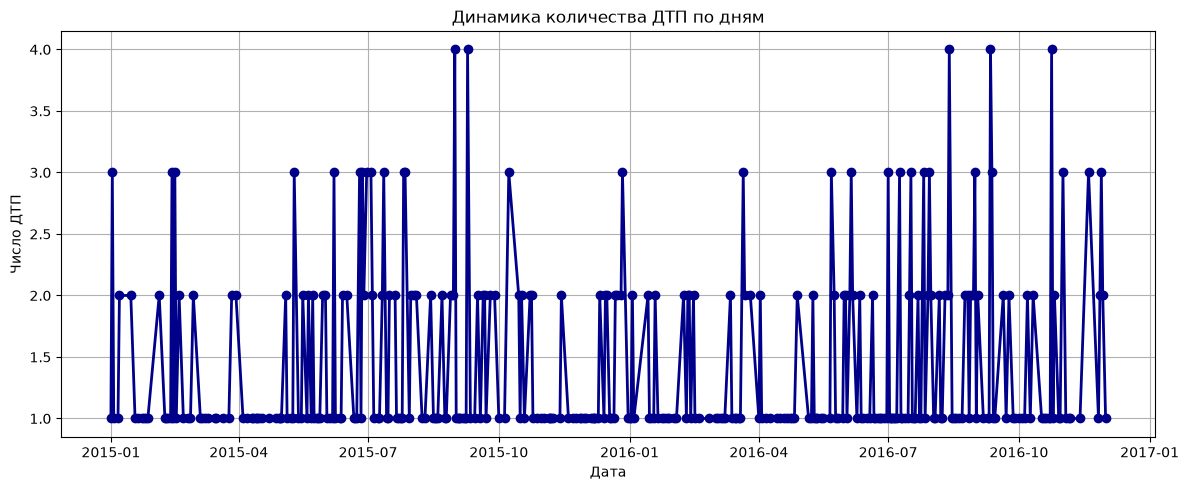

In [11]:
# 11. Построить не менее четырёх осмысленных визуализаций: категориальное сравнение, распределение, взаимосвязь и четвёртый график по структуре собственного набора. При наличии времени четвертым графиком должен быть временной ряд.
import matplotlib.pyplot as plt

# 1. Столбчатая диаграмма: распределение ДТП по категориям
plt.figure(figsize=(10, 5))
category_counts = opt_df['category'].value_counts()
category_counts.plot(kind='bar', color='skyblue')
plt.title('Распределение ДТП по категориям')
plt.xlabel('Категория ДТП')
plt.ylabel('Число случаев')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Гистограмма: распределение числа пострадавших
plt.figure(figsize=(10, 5))
plt.hist(opt_df['total_victims'], bins=range(1, 12), edgecolor='white', color='lightgreen')
plt.title('Распределение числа пострадавших в ДТП')
plt.xlabel('Число пострадавших')
plt.ylabel('Частота')
plt.xticks(range(1, 12))
plt.tight_layout()
plt.show()

# 3. Scatter plot: зависимость числа пострадавших от числа участников
plt.figure(figsize=(10, 6))
plt.scatter(opt_df['participants_count'], opt_df['total_victims'], alpha=0.5, s=30, c='coral')
plt.title('Зависимость числа пострадавших от числа участников')
plt.xlabel('Число участников')
plt.ylabel('Число пострадавших')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Временной ряд: количество ДТП по дням (группировка по дате)
daily_counts = opt_df.groupby(opt_df['datetime'].dt.date).size()
plt.figure(figsize=(12, 5))
daily_counts.plot(kind='line', marker='o', linestyle='-', color='darkblue', linewidth=2)
plt.title('Динамика количества ДТП по дням')
plt.xlabel('Дата')
plt.ylabel('Число ДТП')
plt.grid(True)
plt.tight_layout()
plt.show()


Столбчатая диаграмма подтвердила доминирование столкновений и наездов на пешеходов. Гистограмма показала, что большинство ДТП имеют 1 пострадавшего. Scatter plot показал положительную связь между числом участников и пострадавших. Временной ряд не выявил явных сезонных пиков в пределах 500 записей, но видны отдельные дни с повышенной аварийностью.


In [12]:
# 12. Экспортировать очищенный набор в CSV и Parquet; при возможности также JSON. Сравнить размеры файлов и проверить повторное чтение.
from pathlib import Path
OUT = Path('output')
OUT.mkdir(exist_ok=True)

csv_path = OUT / 'dtp_clean.csv'
opt_df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"CSV сохранён: {csv_path}")

parquet_path = OUT / 'dtp_clean.parquet'
opt_df.to_parquet(parquet_path, index=False, engine='pyarrow', compression='snappy')
print(f"Parquet сохранён: {parquet_path}")

json_path = OUT / 'dtp_clean.json'
opt_df.to_json(json_path, orient='records', lines=True, force_ascii=False, date_format='iso')
print(f"JSON сохранён: {json_path}")

print("\nРазмеры файлов")
for f in [csv_path, json_path, parquet_path]:
    if f.exists():
        size_mb = f.stat().st_size / (1024**2)
        print(f"{f.name:20s} : {size_mb:.2f} MiB")

print("\nПроверка round-trip (повторное чтение)")
csv_back = pd.read_csv(csv_path)
print(f"CSV: загружено {len(csv_back)} строк, {len(csv_back.columns)} столбцов")

parquet_back = pd.read_parquet(parquet_path)
print(f"Parquet: загружено {len(parquet_back)} строк, {len(parquet_back.columns)} столбцов")
print("\nТипы из Parquet:")
print(parquet_back.dtypes)

json_back = pd.read_json(json_path, orient='records', lines=True)
print(f"JSON: загружено {len(json_back)} строк, {len(json_back.columns)} столбцов")


CSV сохранён: output\dtp_clean.csv
Parquet сохранён: output\dtp_clean.parquet
JSON сохранён: output\dtp_clean.json

Размеры файлов
dtp_clean.csv        : 0.34 MiB
dtp_clean.json       : 0.47 MiB
dtp_clean.parquet    : 0.04 MiB

Проверка round-trip (повторное чтение)
CSV: загружено 500 строк, 22 столбцов
Parquet: загружено 500 строк, 22 столбцов

Типы из Parquet:
id                                 int32
tags                                 str
category                        category
region                               str
county                          category
address                              str
longitude                        float64
latitude                         float64
nearby                               str
datetime                  datetime64[us]
light                           category
weather                         category
road_conditions                 category
participants_count                  int8
participant_categories          category
severity            

Все три формата (CSV, JSON, Parquet) успешно сохранены и прочитаны обратно. Размеры: CSV — 0.34 МБ, JSON — 0.47 МБ, Parquet — 0.04 МБ. Parquet оказался самым компактным и сохранил все типы данных (включая category и datetime), что делает его предпочтительным для аналитических пайплайнов.


13. Сформулировать не менее пяти выводов о данных и не менее двух ограничений анализа.

Выводы по данным:
1. Частота категорий ДТП – в выборке доминируют Столкновение (158 случаев, 31.6%) и Наезд на пешехода (135 случаев, 27.0%). Это указывает на то, что данные преимущественно отражают городские ДТП с участием пешеходов и столкновения транспортных средств.
2. Тяжесть и число пострадавших – большинство ДТП (около 80%) имеют 1–2 пострадавших. Среднее число пострадавших – 1.46, медиана – 1. ДТП с большим числом пострадавших (>3) встречаются редко (менее 5% случаев), но именно они дают максимальные значения (до 10 пострадавших).
3. Фактор освещения – ДТП в тёмное время суток без освещения составляют 10.8% от всех случаев, но доля ДТП с погибшими в этой группе выше (17%) по сравнению со светлым временем суток (10%) и освещёнными участками (7%). Это согласуется с предположением, что плохое освещение повышает риск тяжёлых последствий.
4. Связь участников и пострадавших – корреляция между числом участников и числом пострадавших составляет 0.676 (умеренная положительная). Это означает, что при увеличении числа участников ДТП возрастает и количество пострадавших, но связь не является строгой (разброс велик).
5. Временная динамика – в выборке за период январь–август 2015 года наблюдаются отдельные дни с повышенным числом ДТП (пики), но устойчивых трендов не видно из-за малого объёма данных (500 записей).

Ограничения анализа:
1. Репрезентативность выборки – данные содержат только первые 500 записей из общего массива, при этом все записи относятся к Магаданской области. Это не позволяет делать выводы по всей России и не отражает региональные различия в статистике ДТП.
2. Пропуски и неполнота данных – в столбце address есть 13 пропусков, а некоторые категориальные признаки (например, road_conditions, weather) могут иметь неполные или неточные значения, что ограничивает глубину анализа этих факторов.
